In [1]:
pip install networkx

mambajs 0.21.1

Process pip requirements ...



In [13]:
import gzip
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
import math
import random

In [3]:
def create_graph_from_file(file_path):
    G = nx.Graph()
    with gzip.open(file_path, "rt", encoding="utf-8") as f:
        for line in f:
            if not line.strip() or line.startswith("#"): continue
            parts = line.split()
            if len(parts) < 2: continue
            u, v = map(int, parts[:2])
            if u != v: G.add_edge(u, v)
    return G

In [4]:
G_original = create_graph_from_file("flickrEdges.txt.gz")
num_components_orig = nx.number_connected_components(G_original)
comp_sizes = sorted([len(c) for c in nx.connected_components(G_original)], reverse=True)

largest_cc_nodes = max(nx.connected_components(G_original), key=len)
H = G_original.subgraph(largest_cc_nodes).copy()
N = H.number_of_nodes()
E = H.number_of_edges()
degrees = list(dict(H.degree()).values())
min_deg = min(degrees)
max_deg = max(degrees)
avg_deg = sum(degrees) / N
density = nx.density(H)
triangles = sum(nx.triangles(H).values()) // 3
clustering = nx.approximation.average_clustering(H, trials=5000)

In [5]:
print(f"Número de vértices: {N}")
print(f"Número de arestas: {E}")
print(f"Grau - Mín: {min_deg} | Máx: {max_deg} | Médio: {avg_deg:.4f}")
print(f"Densidade: {density:.8f}")
print(f"Número de componentes originais: {num_components_orig}")
print(f"Tamanho componentes: Maior: {comp_sizes[0]} | Outras (Top 5): {comp_sizes[1:6]}")
print(f"Coef. Clusterização (Aprox): {clustering:.4f}")
print(f"Número de Triângulos: {triangles}")

Número de vértices: 105722
Número de arestas: 2316668
Grau - Mín: 1 | Máx: 5425 | Médio: 43.8257
Densidade: 0.00041454
Número de componentes originais: 83
Tamanho componentes: Maior: 105722 | Outras (Top 5): [11, 10, 8, 6, 5]
Coef. Clusterização (Aprox): 0.0924
Número de Triângulos: 107986951


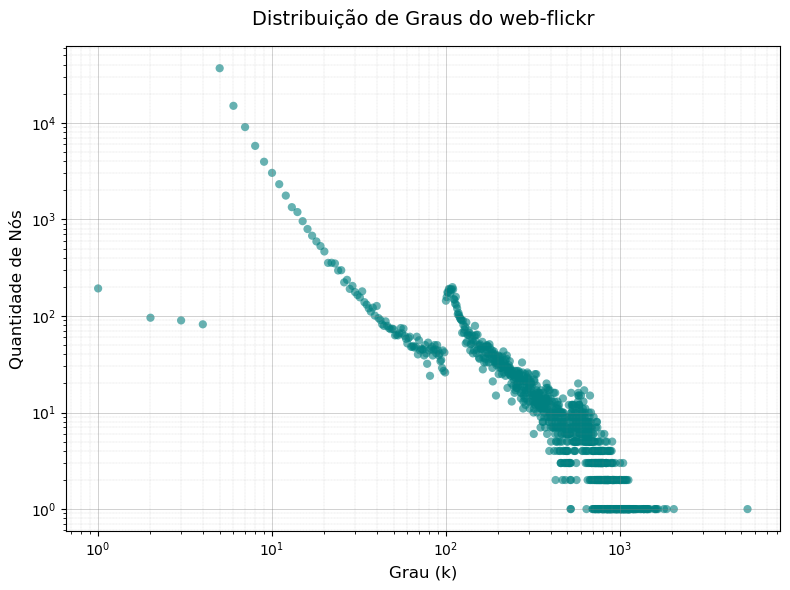

In [14]:
# Gerar gráfico de distribuição de graus
plt.figure(figsize=(8, 6))
degree_counts = nx.degree_histogram(H)

x_filtered = []
y_filtered = []
for i, count in enumerate(degree_counts):
    if count > 0:
        x_filtered.append(i)
        y_filtered.append(count)

plt.scatter(x_filtered, y_filtered, color='teal', alpha=0.6, edgecolors='none', s=35)
plt.xscale('log')
plt.yscale('log')
plt.title("Distribuição de Graus do web-flickr", fontsize=14, pad=15)
plt.xlabel("Grau (k)", fontsize=12)
plt.ylabel("Quantidade de Nós", fontsize=12) # Eixo Y alterado
plt.grid(True, which="major", color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(True, which="minor", color='gray', linestyle='--', linewidth=0.2, alpha=0.5)
plt.tight_layout()
plt.savefig("distribuicao_graus_quantidade.png", dpi=300)
plt.show()


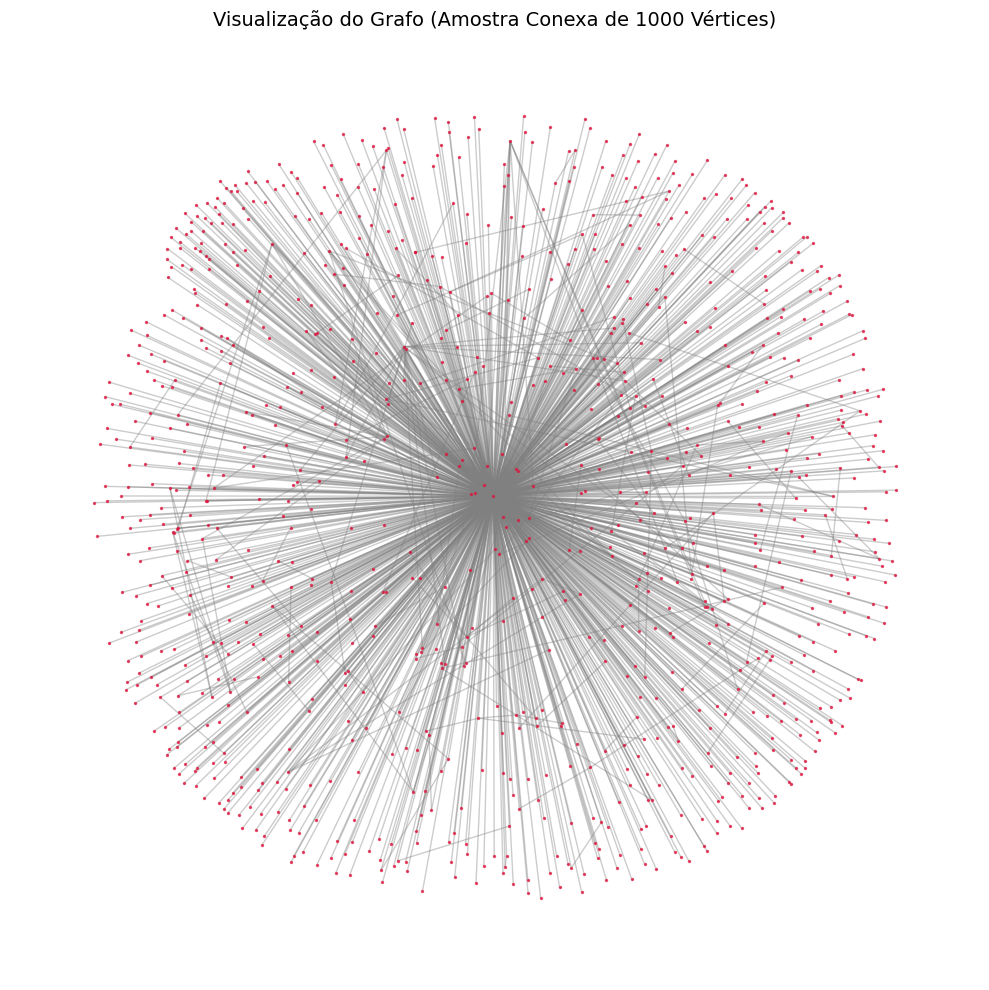

In [17]:
# Gerar grafos com amostragem (number_of_nodes determina o tamanho da amostragem)
number_of_nodes = 1000
degree_dict = dict(H.degree())
start_node = max(degree_dict, key=degree_dict.get)

sample_nodes = set([start_node])
queue = [start_node]

random.seed(42)
while len(sample_nodes) < number_of_nodes and queue:
    current = queue.pop(0)
    neighbors = list(H.neighbors(current))
    random.shuffle(neighbors) 
    for neighbor in neighbors:
        if neighbor not in sample_nodes:
            sample_nodes.add(neighbor)
            queue.append(neighbor)
            if len(sample_nodes) >= number_of_nodes:
                break

subgrafo_viz = H.subgraph(sample_nodes)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(subgrafo_viz, iterations=15, seed=42)

nx.draw_networkx_nodes(subgrafo_viz, pos, node_size=2, node_color='crimson', alpha=0.7)
nx.draw_networkx_edges(subgrafo_viz, pos, alpha=0.4, edge_color='gray')

plt.title(f"Visualização do Grafo (Amostra Conexa de {number_of_nodes} Vértices)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig(f"visualizacao_amostra_{number_of_nodes}.png", dpi=400)
plt.show()

In [6]:
# Teste para Small World
p_er = (2 * E) / (N * (N - 1))
G_rand = nx.fast_gnp_random_graph(N, p_er, seed=42)
C_rand = nx.approximation.average_clustering(G_rand, trials=1000)

amostra_L = random.sample(list(H.nodes()), min(100, N))
L_H = np.mean([np.mean(list(nx.single_source_shortest_path_length(H, n).values())) for n in amostra_L])

lcc_rand_nodes = max(nx.connected_components(G_rand), key=len)
H_rand = G_rand.subgraph(lcc_rand_nodes)
amostra_L_rand = random.sample(list(H_rand.nodes()), min(100, len(H_rand)))
L_rand = np.mean([np.mean(list(nx.single_source_shortest_path_length(H_rand, n).values())) for n in amostra_L_rand])

sigma = (clustering / C_rand) / (L_H / L_rand) if C_rand > 0 and L_rand > 0 else 0
print(f"Sigma (Small-World): {sigma:.4f} (Se > 1, é Mundo Pequeno!)")

Sigma (Small-World): 0.0000 (Se > 1, é Mundo Pequeno!)


In [8]:
# Teste para robustez -> Remoção Aleatória
H_rand_attack = H.copy()
nodes_to_remove = random.sample(list(H.nodes()), int(N * 0.05))
H_rand_attack.remove_nodes_from(nodes_to_remove)
lcc_rand_attack = len(max(nx.connected_components(H_rand_attack), key=len))
perc_rand = (lcc_rand_attack / N) * 100
print(f"Tamanho após remoção aleatória: {perc_rand:.2f}% do original")

Tamanho após remoção aleatória: 94.99% do original


In [9]:
#Teste para robustez -> Remoção dos 5% mais conectados
H_hub_attack = H.copy()
degree_dict = dict(H.degree())
top_hubs = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:int(N * 0.05)]
H_hub_attack.remove_nodes_from([n for n, d in top_hubs])
lcc_hub_attack = len(max(nx.connected_components(H_hub_attack), key=len)) if len(H_hub_attack) > 0 else 0
perc_hub = (lcc_hub_attack / N) * 100
print(f"Tamanho após remoção direcionada: {perc_hub:.2f}% do original")

Tamanho após remoção direcionada: 90.51% do original


In [10]:
num_execucoes = 30
Z_alpha_2 = 1.96

def avaliar_algoritmo(nome, func, *args, **kwargs):
    tempos = []
    for _ in range(num_execucoes):
        inicio = time.time()
        resultado = func(*args, **kwargs)
        if hasattr(resultado, '__iter__') and not isinstance(resultado, (dict, list, bool)):
            list(resultado) 
        fim = time.time()
        tempos.append(fim - inicio)
        
    media = np.mean(tempos)
    desvio = np.std(tempos, ddof=1)
    margem = Z_alpha_2 * (desvio / math.sqrt(num_execucoes))
    print(f"[{nome}] Média: {media:.5f}s | Desvio: {desvio:.5f}s | IC: [{media - margem:.5f}s, {media + margem:.5f}s]")

start_node = random.choice(list(H.nodes()))

avaliar_algoritmo("BFS", nx.bfs_edges, H, start_node)
avaliar_algoritmo("DFS", nx.dfs_edges, H, start_node)
avaliar_algoritmo("Eulerianidade", nx.is_eulerian, H)
avaliar_algoritmo("Dijkstra", nx.single_source_dijkstra_path_length, H, start_node)
avaliar_algoritmo("Kruskal/Prim (MST)", nx.minimum_spanning_tree, H)
avaliar_algoritmo("Tarjan (Biconexas)", nx.biconnected_components, H)

[BFS] Média: 3.76107s | Desvio: 1.26888s | IC: [3.30700s, 4.21513s]
[DFS] Média: 2.29783s | Desvio: 1.07389s | IC: [1.91355s, 2.68212s]
[Eulerianidade] Média: 0.00000s | Desvio: 0.00000s | IC: [0.00000s, 0.00000s]
[Dijkstra] Média: 2.59193s | Desvio: 0.04274s | IC: [2.57664s, 2.60723s]
[Kruskal/Prim (MST)] Média: 23.08110s | Desvio: 9.84296s | IC: [19.55884s, 26.60336s]
[Tarjan (Biconexas)] Média: 7.55727s | Desvio: 3.25530s | IC: [6.39237s, 8.72216s]
